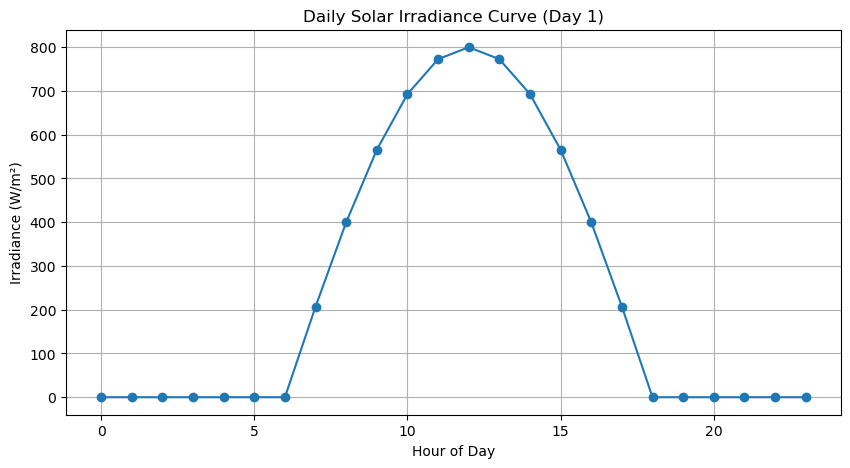

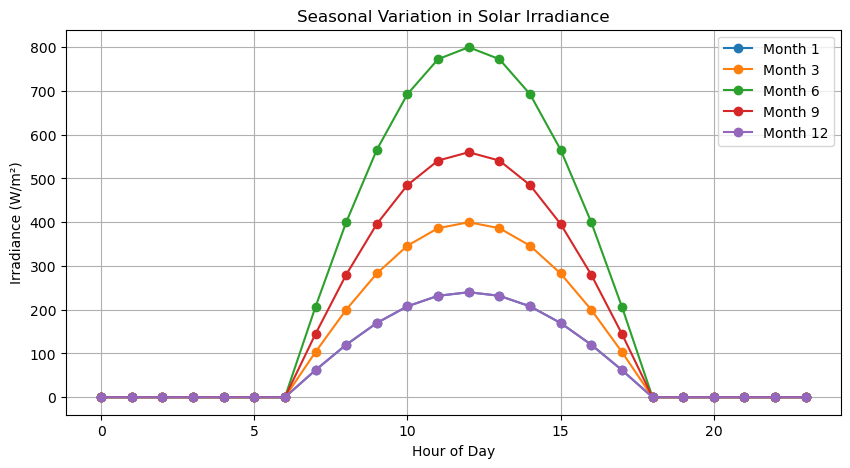

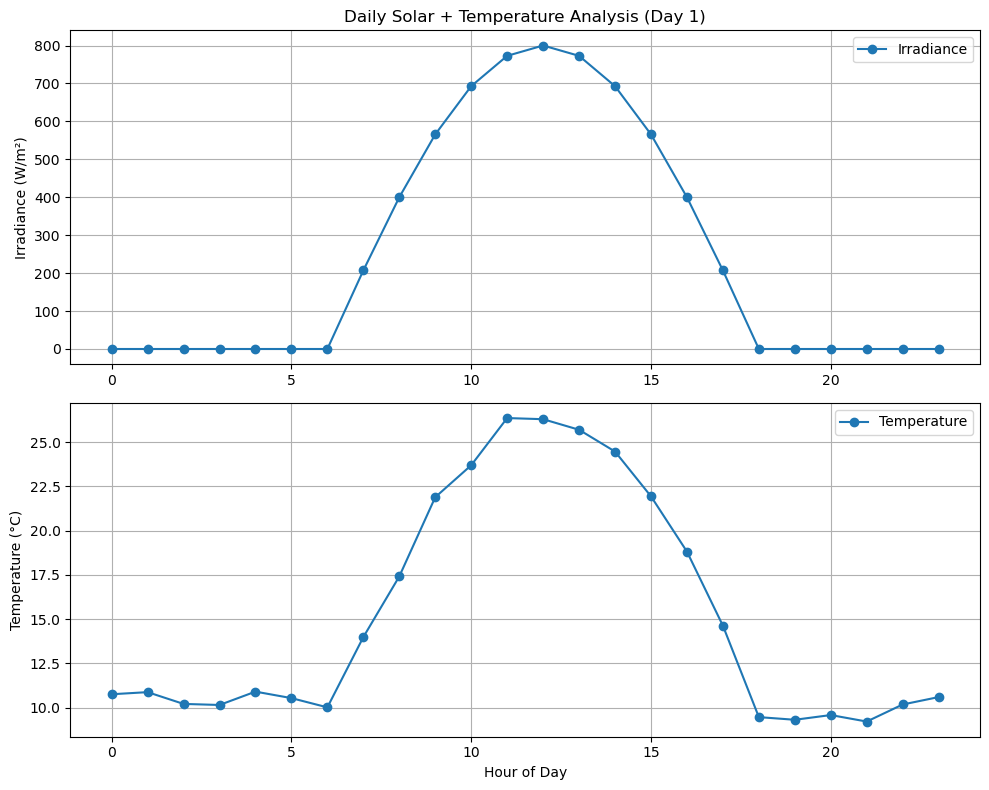

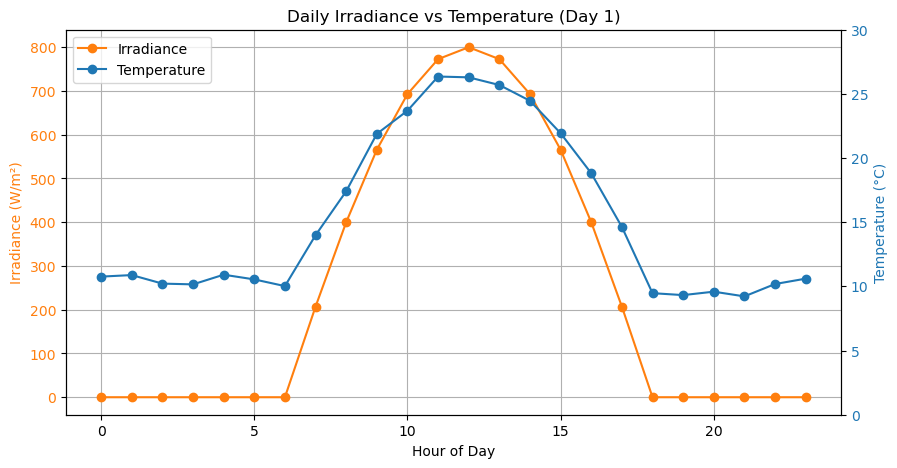

Dataset sample: 
[{'day': 1, 'hour': 0, 'irradiance': 0, 'temperature': 10.76187629030255}, {'day': 1, 'hour': 1, 'irradiance': 0, 'temperature': 10.881370906064367}, {'day': 1, 'hour': 2, 'irradiance': 0, 'temperature': 10.216578558437163}, {'day': 1, 'hour': 3, 'irradiance': 0, 'temperature': 10.157115989293265}, {'day': 1, 'hour': 4, 'irradiance': 0, 'temperature': 10.910292814945654}, {'day': 1, 'hour': 5, 'irradiance': 0, 'temperature': 10.544397711134495}, {'day': 1, 'hour': 6, 'irradiance': 0, 'temperature': 10.022202670456048}, {'day': 1, 'hour': 7, 'irradiance': 207.0552360820166, 'temperature': 13.987408461078068}, {'day': 1, 'hour': 8, 'irradiance': 399.99999999999994, 'temperature': 17.413242880773993}, {'day': 1, 'hour': 9, 'irradiance': 565.685424949238, 'temperature': 21.884629143700714}, {'day': 1, 'hour': 10, 'irradiance': 692.8203230275509, 'temperature': 23.689279155752416}, {'day': 1, 'hour': 11, 'irradiance': 772.7406610312546, 'temperature': 26.352972781573218}]



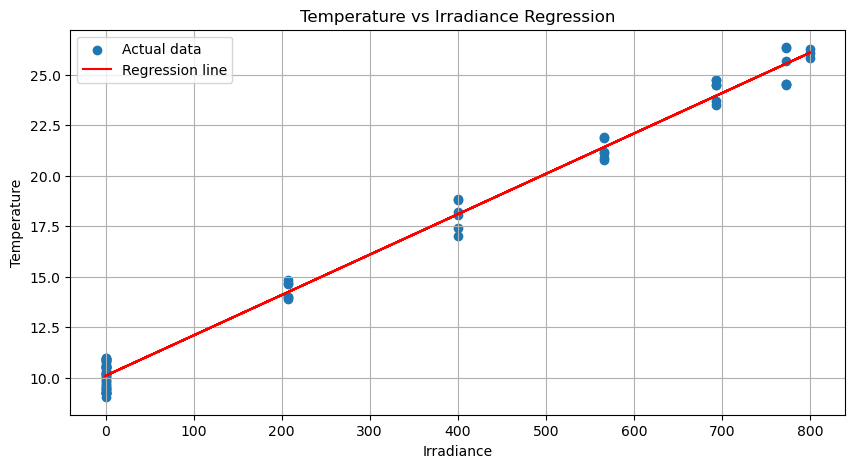

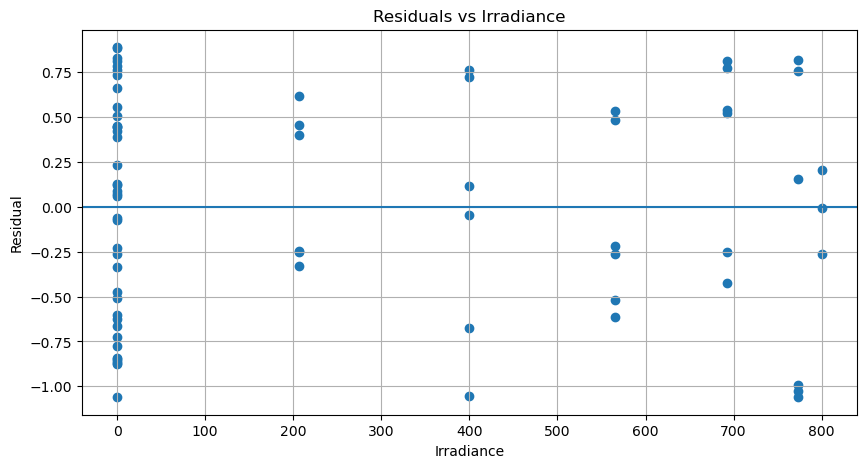

Slope: 0.019981147774749405
Intercept: 10.09721332127577
MSE: 0.363
RMSE: 0.602


In [14]:
import math
import matplotlib.pyplot as plt
import random

{
    "date": "YYYY-MM-DD",         #String
    "hour": int,                 #Integer
    "temperature": float,
    "irradiance": float
}

def seasonal_factor(month):
    """Models a seasonal factor, where irradiance is stronger in summer months"""
    if month in [6, 7]:
        return 1.0              # peak summer
    elif month in [4, 5, 8, 9]:
        return 0.7              # spring/autumn
    elif month in [2, 3, 10, 11]:
        return 0.5              # transitional months
    elif month in [12, 1]:
        return 0.3              # winter
    else:
        return 0.5              #Safety fallback
        
def compute_irradiance(hour, month):
    """Calculates irradiance based on equation I = A((pi/12)*(h-6))
    where A = max irradiance, h = hour (0-24) 
    and 12 is the number of hours of sunlight, 
    assuming sunrise at 6am, and sunset at 6pm"""
    
    A = 800
    angle = (math.pi / 12) * (hour - 6)
    base = math.sin(angle)

    irradiance = A * base

    return max(0, irradiance * seasonal_factor(month))   #Return whichever is bigger: 0 or value

def compute_temperature(irradiance):
    """Calculates temperature based on level of irradiance, 
    with a base level of 10 degrees C"""
    
    base_temp = 10  # typical baseline (°C)

    signal = base_temp + (irradiance * 0.02)

    noise = random.uniform(-1.0, 1.0)   # Generate a random decimal number between -1 and +1

    temp = signal + noise

    return temp

def generate_dataset(month):
    """Generates set of data including day, hour, irradiance and temperature"""
    
    dataset = []
    
    for day in range(1, 4):        #Generates data for the days given (here the first 3 (1, 4)
        for hour in range(24):
            record = {}
            record["day"] = day
            record["hour"] = hour
        
            # Irradiance
            irr = compute_irradiance(hour, month)
            record["irradiance"] = irr
            
            # Temperature (NEW)
            record["temperature"] = compute_temperature(irr)
    
            dataset.append(record)
           
    return dataset

def filter_by_value(dataset, key, value):
    """Filters dataset by a given value"""
    
    result = []
    
    for r in dataset:
        if r[key] == value:
            result.append(r)
    
    return result

# --------------------------------
# Initial model plotting functions
# --------------------------------

def plot_daily_irradiance(dataset, day_value):

    day_data = filter_by_value(dataset, "day", day_value)

    hours = []
    irradiance = []

    for r in day_data:
        hours.append(r["hour"])
        irradiance.append(r["irradiance"])

    plt.figure(figsize=(10,5))
    plt.plot(hours, irradiance, marker="o")

    plt.xlabel("Hour of Day")
    plt.ylabel("Irradiance (W/m²)")
    plt.title(f"Daily Solar Irradiance Curve (Day {day_value})")

    plt.grid(True)

    plt.savefig("daily_solar_irradiance_curve.png", dpi=300)
    plt.show()
    
def plot_seasonal_irradiance(months):

    plt.figure(figsize=(10,5))

    for month in months:

        hours = []
        irradiance = []

        for hour in range(24):

            hours.append(hour)

            irr = compute_irradiance(hour, month)
            irradiance.append(irr)

        plt.plot(
            hours,
            irradiance,
            marker="o",
            label=f"Month {month}"
        )

    plt.xlabel("Hour of Day")
    plt.ylabel("Irradiance (W/m²)")
    plt.title("Seasonal Variation in Solar Irradiance")

    plt.grid(True)
    plt.legend()

    plt.savefig(
        "seasonal_variation_in_solar_irradiance.png",
        dpi=300
    )

    plt.show()
    
def plot_daily_analysis(dataset, day_value):
    day_data = []

    for r in dataset:
        if r["day"] == day_value:
            day_data.append(r)

    hours = []
    irradiance = []
    temperature = []

    for r in day_data:
        hours.append(r["hour"])
        irradiance.append(r["irradiance"])
        temperature.append(r["temperature"])

    fig, axes = plt.subplots(2, 1, figsize=(10,8))   #Creates two separate plots, based on same dataset analysis

    # ------------------------
    # Top plot: Irradiance                           #Each plot needs its own axis defining
    # ------------------------
    axes[0].plot(hours, irradiance, label="Irradiance", marker="o")
    axes[0].set_title(f"Daily Solar + Temperature Analysis (Day {day_value})")
    axes[0].set_ylabel("Irradiance (W/m²)")
    axes[0].grid(True)
    axes[0].legend()

    # ------------------------
    # Bottom plot: Temperature
    # ------------------------
    axes[1].plot(hours, temperature, label="Temperature", marker="o")
    axes[1].set_xlabel("Hour of Day")
    axes[1].set_ylabel("Temperature (°C)")
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("daily_solar_and_temperature_analysis.png", dpi=300) 
    plt.show()
   
def plot_daily_twin_axis(dataset, day_value):   
    """Plts both irradiance and temp on same graph, different y-axes"""
    # -----------------------------
    # Filter data for selected day
    # -----------------------------
    day_data = []

    for r in dataset:
        if r["day"] == day_value:
            day_data.append(r)

    # -----------------------------
    # Extract lists
    # -----------------------------
    hours = []
    irradiance = []
    temperature = []

    for r in day_data:
        hours.append(r["hour"])
        irradiance.append(r["irradiance"])
        temperature.append(r["temperature"])

    # -----------------------------
    # Create figure + primary axis
    # -----------------------------
    fig, ax1 = plt.subplots(figsize=(10,5))

    # Irradiance (left axis)
    ax1.plot(hours, irradiance, color="tab:orange", marker="o", label="Irradiance")
    ax1.set_xlabel("Hour of Day")
    ax1.set_ylabel("Irradiance (W/m²)", color="tab:orange")
    ax1.tick_params(axis='y', labelcolor="tab:orange")
    ax1.grid(True)

    # -----------------------------
    # Secondary axis (temperature)
    # -----------------------------
    ax2 = ax1.twinx()

    ax2.set_ylim(0, 30)          #Sets different height of second y-axis so plots don't overlap.
    ax2.plot(hours, temperature, color="tab:blue", marker="o", label="Temperature")
    ax2.set_ylabel("Temperature (°C)", color="tab:blue")
    ax2.tick_params(axis='y', labelcolor="tab:blue")

    # -----------------------------
    # Title + layout
    # -----------------------------
    plt.title(f"Daily Irradiance vs Temperature (Day {day_value})")

    # Optional: combined legend handling
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
    plt.savefig("daily_irradiance_vs_temperature.png", dpi=300) 
    plt.show()

# -----------------------------
# Reusable Regression Pipeline                  # x_values and y_values can be used for multiple different variables
# -----------------------------

def extract_regression_variables(dataset):
    """Extract inputs and targets for regression"""

    x_values = []
    y_values = []

    for record in dataset:
        x_values.append(record["irradiance"])
        y_values.append(record["temperature"])

    return x_values, y_values

def compute_mean(values):
    """Compute the mean of a list of numeric values."""
    total = 0
    count = 0

    for value in values:
        if value is not None:
            total += value
            count += 1

    if count == 0:
        return None

    average = total / count
    return average
    
def fit_linear_regression(x_values, y_values):  
    """Regression parameter calculation"""
    
    mean_x = compute_mean(x_values)
    mean_y = compute_mean(y_values)

    products = []
    x_squares = []

    for x, y in zip(x_values, y_values):
        dx = x - mean_x
        dy = y - mean_y
        products.append(dx * dy)
        x_squares.append(dx * dx)

    sum_products = sum(products)
    sum_x_squares = sum(x_squares)

    m = sum_products / sum_x_squares
    b = mean_y - m * mean_x

    return m, b, mean_x, mean_y

def predict(x_values, m, b):           #Using the parameter x_values means we can apply this function to any dataset/variable
    """Prediction generation"""
    
    predicted_values = []

    for x in x_values:
        y_hat = m * x + b
        predicted_values.append(y_hat)

    return predicted_values

def compute_mse(x_values, y_values, m, b):    
    """Evaluation metrics (MSE/RMSE calculations)"""
    
    squared_errors = []

    for x, y in zip(x_values, y_values):
        y_hat = m * x + b              
        error = y - y_hat              #The residual - difference between predicted value (y_hat) and actual measured value (y)
        squared_error = error ** 2     #Errors are squared so that +ve and -ve erors don't cancel out
        squared_errors.append(squared_error)   
   
    mse = sum(squared_errors) / len(squared_errors)   #Mean squared error (MSE) - the average of the squared errors in °C²
    rmse = math.sqrt(mse)                             #Square root of MSE, gives the error in °C
    
    return mse, rmse

def compute_residuals(x_values, y_values, m, b):     #Residual analysis - residuals, positive/negative split  
    
    residuals = []

    for x, y in zip(x_values, y_values):
        y_hat = m * x + b
        residual = y - y_hat      #Residual same as error (difference between y_hat and y)
        residuals.append(residual)

    return residuals

def run_linear_regression_pipeline(dataset):
    """Automates a reusable regression system into a structured results object:
    Feature extraction
    Model fitting
    Prediction generation
    Error evaluation"""

    # Feature extraction
    x_values, y_values = extract_regression_variables(dataset)

    # Fit linear model
    m, b, mean_x, mean_y = fit_linear_regression(x_values, y_values)
    
    # Predictions
    predicted_y = predict(x_values, m, b)  

    #Evaluation
    mse, rmse = compute_mse(x_values, y_values, m, b)

    residuals = compute_residuals(x_values, y_values, m, b)

    #Return results
    return {
        "m": m,
        "b": b,
        "mse": mse,
        "rmse": rmse,
        "predicted_y": predicted_y,
        "x_values": x_values,
        "y_values": y_values,
        "residuals": residuals
    }

def plot_regression_line(x_values, y_values, predicted_y):
    """Plot x and y values against regression line (x values vs predicted y values)"""
    
    plt.figure(figsize=(10,5))

    plt.scatter(x_values, y_values, label="Actual data")

    plt.plot(x_values, predicted_y, color="red", label="Regression line")

    plt.xlabel("Irradiance")
    plt.ylabel("Temperature")

    plt.title("Temperature vs Irradiance Regression")

    plt.grid(True)
    plt.legend()

    plt.savefig("irradiance_temperature_regression.png", dpi=300)

    plt.show()

def plot_residuals(x_values, residuals):
    """Visualise errors (residuals)"""
    
    plt.figure(figsize=(10,5))

    plt.scatter(x_values, residuals)

    plt.axhline(0)         #Puts horizoatal marker line at y=0

    plt.xlabel("Irradiance")
    plt.ylabel("Residual")

    plt.title("Residuals vs Irradiance")

    plt.grid(True)

    plt.savefig("residuals_vs_irradiance.png", dpi=300)

    plt.show()
    
# -----------------------------
# Control panel
# -----------------------------

# Generate dataset
month = 6
dataset = generate_dataset(month)     #Generates data set for month given above
months = [1, 3, 6, 9, 12]     #Generates temporary curves for visualization

# Initial plotting
plot_daily_irradiance(dataset, 1)
plot_seasonal_irradiance(months)
plot_daily_analysis(dataset, 1)   
plot_daily_twin_axis(dataset, 1)

print(f"Dataset sample: \n{dataset[:12]}\n")  

# Regression pipeline
results = run_linear_regression_pipeline(dataset)

# Extract results
m = results["m"]
b = results["b"]

mse = results["mse"]
rmse = results["rmse"]

predicted_y = results["predicted_y"]
residuals = results["residuals"]

x_values = results["x_values"]
y_values = results["y_values"]

plot_regression_line(x_values, y_values, predicted_y)
plot_residuals(x_values, residuals)

# Print results
print("Slope:", m)
print("Intercept:", b)

print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")

In [10]:
def generate_solar_data(n):
    data = []
    
    for i in range(n):
        pass                      # we'll write this in the next step
    
    return data


In [ ]:
day_1 = filter_by_value(dataset, "day", 1)